In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


## Step 1: Load Data

In [2]:
df = pd.read_csv('../datasets/parkinsons.csv')
if 'name' in df.columns:
    df.drop('name', axis=1, inplace=True)
print('Shape:', df.shape)
print('Class distribution:\n', df['status'].value_counts())
df.head()

Shape: (195, 23)
Class distribution:
 status
1    147
0     48
Name: count, dtype: int64


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## Step 2: EDA

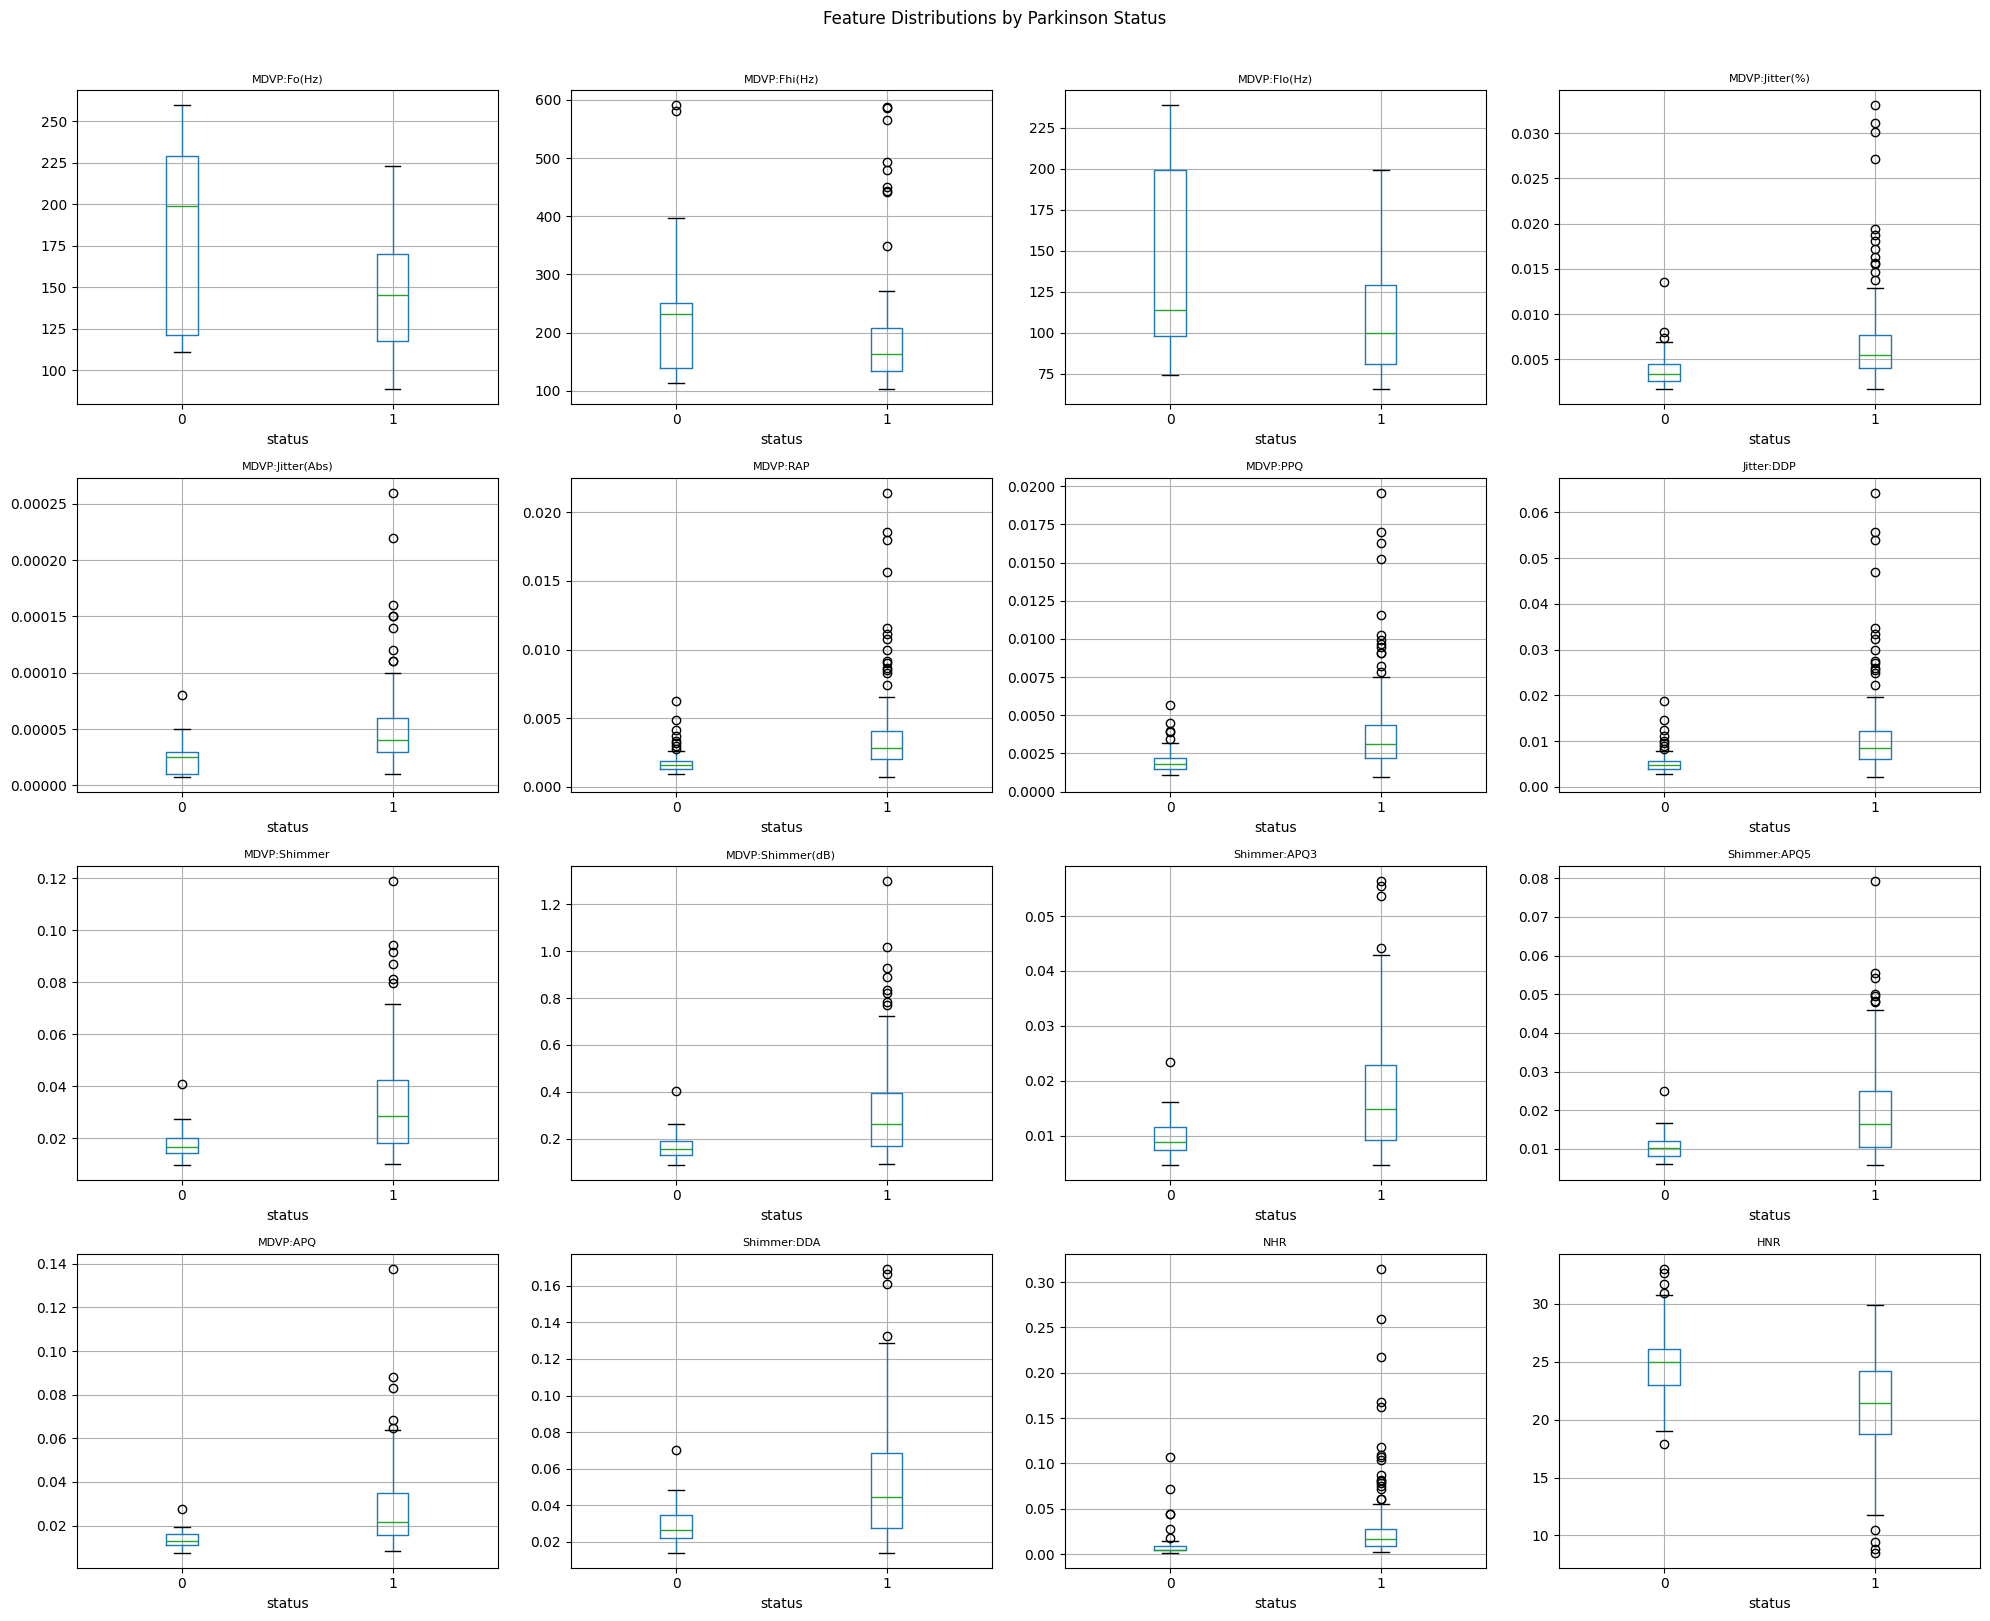

In [3]:
plt.figure(figsize=(20, 16))
for i, col in enumerate(df.columns[:-1][:16]):
    plt.subplot(4, 4, i+1)
    df.boxplot(column=col, by='status', ax=plt.gca())
    plt.title(col, fontsize=8)
    plt.suptitle('')
plt.suptitle('Feature Distributions by Parkinson Status', y=1.01)
plt.tight_layout()
plt.show()

## Step 3: Preprocessing

In [5]:
X = df.drop('status', axis=1)
y = df['status']
# CRITICAL: Scaling is mandatory for SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (156, 22), Test: (39, 22)


## Step 4: Baseline Model

In [6]:
baseline = SVC(kernel='rbf', probability=True, random_state=42)
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
baseline_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])
print(f'Baseline Accuracy : {baseline_acc:.4f}')
print(f'Baseline ROC-AUC  : {baseline_auc:.4f}')

Baseline Accuracy : 0.9231
Baseline ROC-AUC  : 0.9552


## Step 5: Hyperparameter Tuning (GridSearchCV)

In [7]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'poly']
}
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best CV ROC-AUC:', f'{grid_search.best_score_:.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV ROC-AUC: 0.9765


## Step 6: Tuned Model Evaluation

In [8]:
model = grid_search.best_estimator_
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_prob)
print(f'Tuned Accuracy : {tuned_acc:.4f}  (Baseline: {baseline_acc:.4f})  Gain: {tuned_acc - baseline_acc:+.4f}')
print(f'Tuned ROC-AUC  : {tuned_auc:.4f}  (Baseline: {baseline_auc:.4f})  Gain: {tuned_auc - baseline_auc:+.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=['Healthy','Parkinsons']))

Tuned Accuracy : 0.8718  (Baseline: 0.9231)  Gain: -0.0513
Tuned ROC-AUC  : 0.9724  (Baseline: 0.9552)  Gain: +0.0172

Classification Report:
               precision    recall  f1-score   support

     Healthy       0.73      0.80      0.76        10
  Parkinsons       0.93      0.90      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.85      0.84        39
weighted avg       0.88      0.87      0.87        39



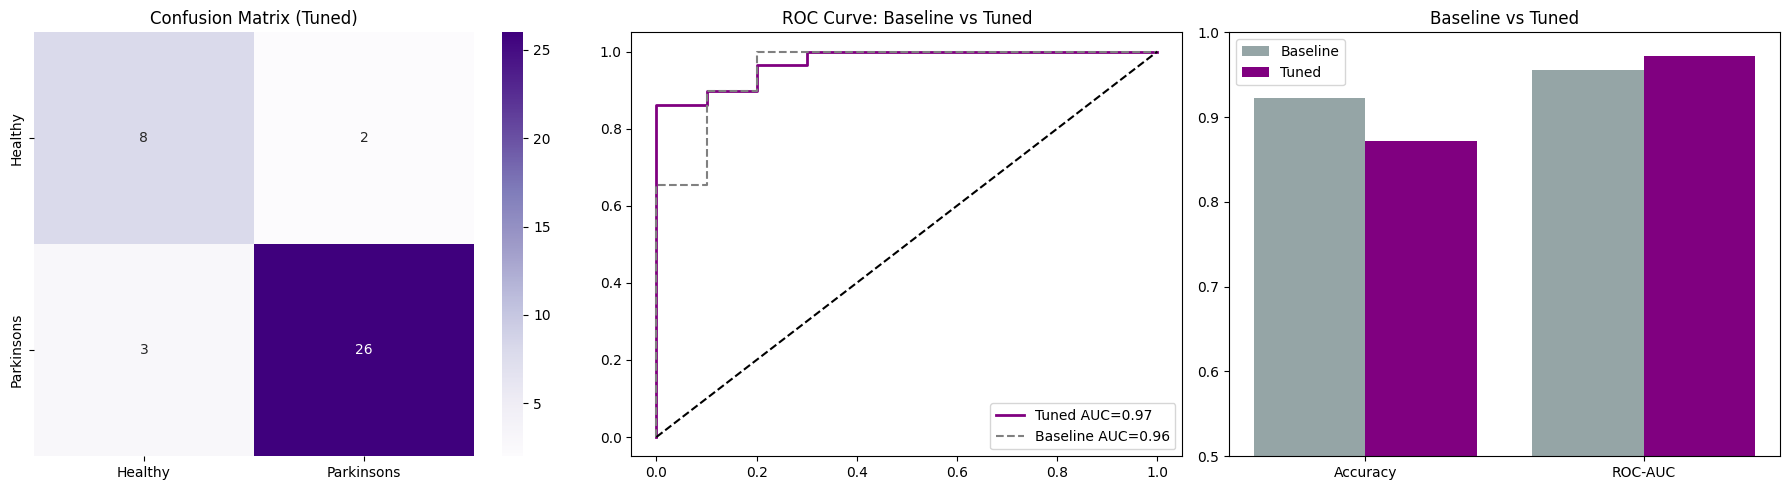

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Healthy','Parkinsons'], yticklabels=['Healthy','Parkinsons'])
axes[0].set_title('Confusion Matrix (Tuned)')
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'Tuned AUC={tuned_auc:.2f}')
fpr_b, tpr_b, _ = roc_curve(y_test, baseline.predict_proba(X_test)[:,1])
axes[1].plot(fpr_b, tpr_b, color='gray', lw=1.5, linestyle='--', label=f'Baseline AUC={baseline_auc:.2f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve: Baseline vs Tuned')
axes[1].legend()
x = np.arange(2)
axes[2].bar(x-0.2, [baseline_acc, baseline_auc], 0.4, label='Baseline', color='#95a5a6')
axes[2].bar(x+0.2, [tuned_acc, tuned_auc], 0.4, label='Tuned', color='purple')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Accuracy','ROC-AUC'])
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title('Baseline vs Tuned')
axes[2].legend()
plt.tight_layout()
plt.show()

## Step 7: Save Model

In [10]:
joblib.dump(model, '../models/parkinsons_model.pkl')
joblib.dump(scaler, '../models/parkinsons_scaler.pkl')
print('Parkinsons tuned model and scaler saved!')

Parkinsons tuned model and scaler saved!
